# Image Classification with SVM — Handwritten Digits

Our first **image classification** project! We'll teach a Support Vector Machine to recognize **handwritten digits** (0–9) — the classic "MNIST" task that launched a thousand machine-learning careers.

The surprising part: an image is just a **grid of numbers** (how dark each pixel is). Once we see it that way, classifying an image is the *same* job as any other classification — the SVM doesn't know it's looking at a picture, it just sees numbers.

**The plan:**
1. Load the digit images and look at them.
2. See how an image becomes a row of numbers.
3. Train an SVM to recognize digits.
4. Test it, and see which digits it gets right and wrong.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

---
## 1. Load the digit images

scikit-learn includes a dataset of **1,797 handwritten digits**, each an **8×8 pixel** grayscale image. (This is a smaller cousin of the famous MNIST dataset — same task, but built right in so we need no downloads.)

In [6]:
digits = load_digits()

print("number of images:", len(digits.images))
print("images shape : ", digits.images.shape)
print("each image is:", digits.images[0].shape, "pixels")
print("the digits are:", np.unique(digits.target))

number of images: 1797
images shape :  (1797, 8, 8)
each image is: (8, 8) pixels
the digits are: [0 1 2 3 4 5 6 7 8 9]


Let's **look** at some of them — always see your data first.

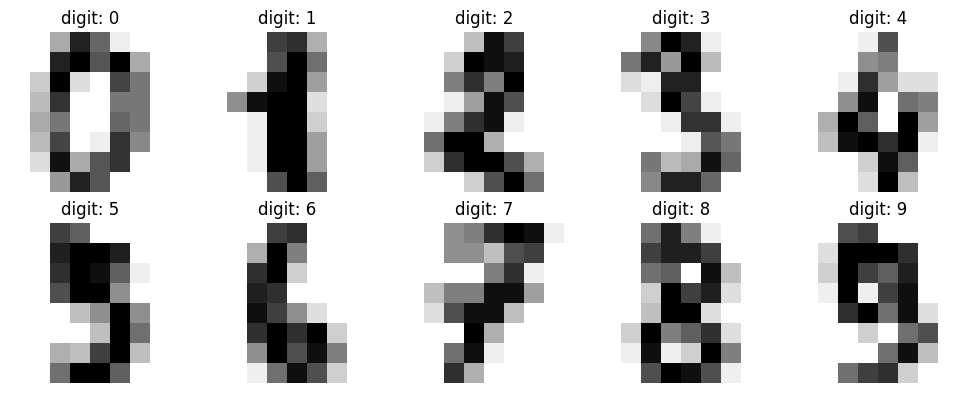

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"digit: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

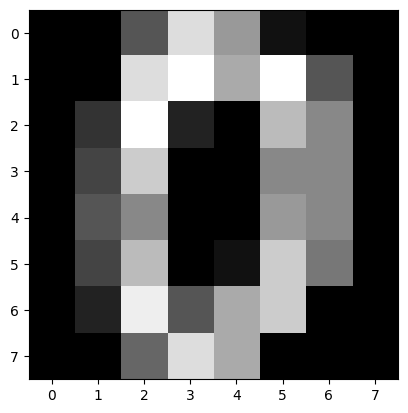

In [18]:
plt.imshow(digits.images[0], cmap='gray')

These are real handwritten digits, blurry and imperfect — just 8×8 pixels each. Our SVM's job is to look at a new one and say which digit it is.

---
## 2. An image is just a grid of numbers

Here's the key idea that makes image classification possible: a grayscale image is a **grid of brightness values**. Each pixel is a number — 0 for white, higher for darker. Let's look at one digit as its raw numbers.

In [17]:
# take the first image and print its pixel values
print("This image shows the digit:", digits.target[0])
print("\nAs an 8x8 grid of pixel brightness (0 = white, 16 = darkest):")
print(digits.images[0].astype(int))

This image shows the digit: 0

As an 8x8 grid of pixel brightness (0 = white, 16 = darkest):
[[ 0  0  5 13  9  1  0  0]
 [ 0  0 13 15 10 15  5  0]
 [ 0  3 15  2  0 11  8  0]
 [ 0  4 12  0  0  8  8  0]
 [ 0  5  8  0  0  9  8  0]
 [ 0  4 11  0  1 12  7  0]
 [ 0  2 14  5 10 12  0  0]
 [ 0  0  6 13 10  0  0  0]]


Squint at those numbers — the larger values (the darker pixels) trace out the shape of the digit. The computer "sees" exactly this grid.

To feed it to the SVM, we **flatten** the 8×8 grid into a single row of 64 numbers. The model treats those 64 pixel values as 64 **features** — no different from the "exam 1, exam 2" features we used before, just more of them.

In [19]:
# the dataset already provides the flattened version: 64 numbers per image
X = digits.data       # shape (1797, 64) — each row is one flattened image
y = digits.target     # the true digit for each image

print("X shape:", X.shape, " → 1797 images, each 64 pixel-features")
print("first image as a flat row of 64 numbers:")
print(X[0].astype(int))

X shape: (1797, 64)  → 1797 images, each 64 pixel-features
first image as a flat row of 64 numbers:
[ 0  0  5 13  9  1  0  0  0  0 13 15 10 15  5  0  0  3 15  2  0 11  8  0
  0  4 12  0  0  8  8  0  0  5  8  0  0  9  8  0  0  4 11  0  1 12  7  0
  0  2 14  5 10 12  0  0  0  0  6 13 10  0  0  0]


---
## 3. Train the SVM

Now it's the same workflow as every classifier — split, scale, fit. The only difference from before is that we have 64 features (pixels) instead of 2, and 10 classes (digits) instead of 2. The code barely changes.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# split into training and test images
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("training images:", len(X_train), " test images:", len(X_test))

training images: 1347  test images: 450


**Scaling matters for SVM** — it works best when all features are on a similar range. We standardize the pixel values (fit the scaler on the training data only, then apply to both).

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# train the SVM — the same three lines as always
model = SVC(kernel="rbf")
model.fit(X_train_scaled, y_train)
print("SVM trained on", len(X_train), "digit images.")

SVM trained on 1347 digit images.


---
## 4. Test it — how well does it recognize digits?

In [23]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print(f"accuracy on unseen test digits: {accuracy:.1%}")

accuracy on unseen test digits: 98.2%


Around **98%** — the SVM recognizes almost every handwritten digit it has never seen before. Let's *look* at some of its predictions.

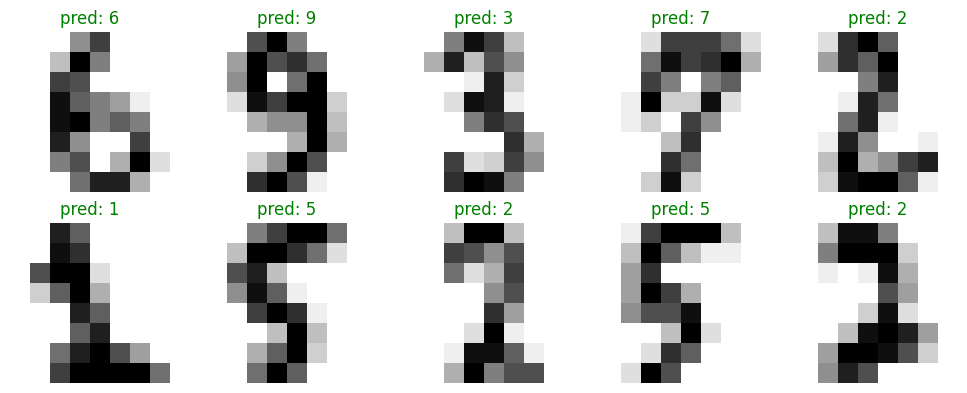

In [25]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, true_label, pred in zip(axes.ravel(), X_test, y_test, predictions):

    ax.imshow(image.reshape(8, 8), cmap="gray_r")
    color = "green" if true_label == pred else "red"
    ax.set_title(f"pred: {pred}", color=color)
    ax.axis("off")
plt.tight_layout()
plt.show()

(-0.5, 7.5, 7.5, -0.5)

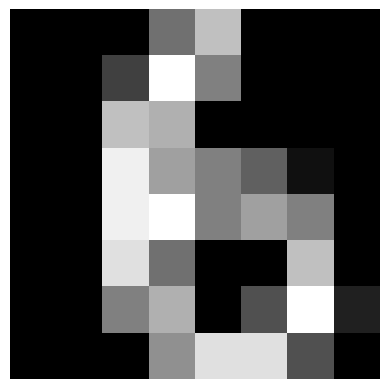

In [32]:
img = X_test[0].reshape(8, 8)
plt.imshow(img, cmap='gray')
plt.axis('off')

In [39]:
img_m = X_test_scaled[0]
img_m = img_m.reshape(1, -1)
img_m.shape

(1, 64)

In [40]:
model.predict(img_m)

array([6])

In [41]:
y_test[0]

6

Green titles are correct predictions. The model reads the handwritten digits just like we do.

### Where does it slip up?
Let's find the mistakes and look at them — they're usually genuinely tricky, messy digits.

In [ ]:
# find the images the model got wrong
wrong = np.where(predictions != y_test)[0]
print(f"the model got {len(wrong)} out of {len(y_test)} wrong")

if len(wrong) > 0:
    fig, axes = plt.subplots(1, min(5, len(wrong)), figsize=(10, 2.5))
    axes = np.atleast_1d(axes)
    for ax, idx in zip(axes, wrong[:5]):
        ax.imshow(X_test[idx].reshape(8, 8), cmap="gray_r")
        ax.set_title(f"true {y_test[idx]}, said {predictions[idx]}", color="red", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

The mistakes are usually **messy or ambiguous** digits — a sloppy 8 that looks like a 1, a 9 that could be a 4. Even a human might hesitate on these. That's reassuring: the model fails where the data is genuinely hard, not randomly.

### The confusion matrix — which digits get mixed up?
With 10 classes, the confusion matrix shows exactly which digits the model confuses with which.

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel("predicted digit"); plt.ylabel("true digit")
plt.title("Confusion matrix — the diagonal is correct predictions")
plt.show()

The strong **diagonal** shows almost everything was classified correctly. The few off-diagonal numbers are the mix-ups — often visually similar digit pairs. A near-perfect diagonal is exactly what a good classifier looks like.

---
## Summary

- An **image is just a grid of numbers** — each pixel's brightness is a feature. An 8×8 image becomes **64 features**.
- Image classification is therefore the **same task** as any other classification — the SVM sees numbers, not pictures.
- The workflow was **identical** to every classifier: `train_test_split` → scale → `SVC().fit()` → predict → evaluate. Only the number of features (64) and classes (10) changed.
- The SVM reached **~98% accuracy** recognizing handwritten digits it had never seen.
- Its mistakes were on **genuinely messy** digits — it fails where the data is hard, not randomly.
- The **confusion matrix** revealed which digit pairs get occasionally mixed up.

This is the foundation of computer vision: turn an image into numbers, then classify. Real MNIST uses larger 28×28 images and 70,000 samples, but the idea you just used is exactly the same — and scales all the way up to the systems that read postal codes, cheques, and forms.